# Assignment 1 — Market Basket Analysis (MBA) on Real-World Data

**Dataset:** UCI *Online Retail* dataset (Chen, D., 2015) — real transaction records from a UK-based online gift retailer, Dec 2010 – Dec 2011.
**Technique:** Apriori algorithm for frequent itemset mining and association-rule generation, implemented with `mlxtend`.

## Table of Contents
1. [What is Market Basket Analysis?](#1)
2. [Formal Definitions](#2)
3. [Dataset Description](#3)
4. [Data Cleaning](#4)
5. [Exploratory Data Analysis](#5)
6. [Building the Transaction–Item Matrix](#6)
7. [Worked Numerical Example (by hand)](#7)
8. [Applying the Apriori Algorithm](#8)
9. [Generating Association Rules](#9)
10. [Visualizing the Rules](#10)
11. [Business Interpretation](#11)
12. [Limitations & Extensions](#12)
13. [Conclusion](#13)


<a id="1"></a>
## 1. What is Market Basket Analysis?

**Market Basket Analysis (MBA)** is a data-mining technique that uncovers relationships between items that customers tend to purchase together. It answers questions like *"customers who buy X also tend to buy Y"* — the foundation of recommendation engines, cross-selling, store-layout design, and bundle promotions.

MBA operates on **transactional data**: each transaction (e.g. one invoice / shopping basket) is a set of items. The goal is to mine **association rules** of the form

$$X \Rightarrow Y$$

meaning "if a customer buys itemset $X$, they are likely to also buy itemset $Y$", where $X$ and $Y$ are disjoint itemsets.

The classic algorithm for this is **Apriori** (Agrawal & Srikant, 1994), which we implement below using the `mlxtend` library on a genuine e-commerce transaction log.

<a id="2"></a>
## 2. Formal Definitions

Let $D = \{t_1, t_2, \dots, t_n\}$ be the set of all transactions (a *transaction database*), and let $X, Y$ be itemsets with $X \cap Y = \emptyset$.

**Support** — the proportion of transactions containing itemset $X$:
$$\text{Support}(X) = \frac{|\{t \in D : X \subseteq t\}|}{|D|}$$

**Confidence** — how often $Y$ appears in transactions that contain $X$:
$$\text{Confidence}(X \Rightarrow Y) = \frac{\text{Support}(X \cup Y)}{\text{Support}(X)}$$

**Lift** — how much more likely $Y$ is purchased when $X$ is purchased, compared to $Y$'s baseline popularity:
$$\text{Lift}(X \Rightarrow Y) = \frac{\text{Confidence}(X \Rightarrow Y)}{\text{Support}(Y)} = \frac{\text{Support}(X \cup Y)}{\text{Support}(X)\cdot \text{Support}(Y)}$$

- $\text{Lift} = 1$: $X$ and $Y$ are statistically independent (no real association).
- $\text{Lift} > 1$: $X$ and $Y$ are **positively** associated (co-occur more than expected by chance).
- $\text{Lift} < 1$: $X$ and $Y$ are **negatively** associated (substitutes).

**Leverage** — the difference between observed and expected co-occurrence:
$$\text{Leverage}(X \Rightarrow Y) = \text{Support}(X \cup Y) - \text{Support}(X)\cdot\text{Support}(Y)$$

**Conviction** — sensitive to rule direction, measures how much the rule would be "wrong" if $X$ and $Y$ were independent:
$$\text{Conviction}(X \Rightarrow Y) = \frac{1 - \text{Support}(Y)}{1 - \text{Confidence}(X \Rightarrow Y)}$$

**The Apriori principle (anti-monotonicity):** *any subset of a frequent itemset must itself be frequent.* Equivalently, if an itemset is infrequent, all its supersets are guaranteed infrequent. This lets Apriori prune the search space level-by-level instead of enumerating all $2^{|I|}$ possible itemsets.

<a id="3"></a>
## 3. Dataset Description

We use the **"Online Retail"** dataset donated by Dr. Daqing Chen (London South Bank University) to the UCI Machine Learning Repository (DOI: 10.24432/C5BW33), also published in *Chen, Sain & Guo (2012), Journal of Database Marketing & Customer Strategy Management*.

> *"This is a transnational data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail. The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers."*

**Raw scale (verified on load):** 541,909 transaction line items, 8 columns (`InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`), spanning 38 countries — over 90% of rows are from the United Kingdom.

For a computationally tractable and clearly interpretable demonstration (a standard simplification used across MBA tutorials on this exact dataset), we focus on the **France** subset — a mid-sized, self-contained market with real repeat-purchase structure. The France subset used here was extracted from the full dataset and cleaned as shown in Section 4; it is shipped alongside this notebook as `online_retail_france.csv` so the analysis is fully reproducible offline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_colwidth', 60)

raw = pd.read_csv('online_retail_france.csv', parse_dates=['InvoiceDate'])
print("Rows loaded:", raw.shape[0], "| Columns:", raw.shape[1])
raw.head()

Rows loaded: 8407 | Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France
1,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France
2,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France
3,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.85,12583.0,France
4,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.65,12583.0,France


<a id="4"></a>
## 4. Data Cleaning

Real-world retail logs need cleaning before mining. We apply the standard steps for this dataset:

1. Drop rows with a missing `Description`.
2. Strip stray whitespace from `Description` (the raw data has inconsistent padding).
3. Remove **cancelled orders** — `InvoiceNo` values starting with `'C'` denote a cancellation, not a purchase.
4. Remove rows with non-positive `Quantity` or `UnitPrice` (returns / data-entry artifacts).

In [2]:
before = raw.shape[0]

df = raw.dropna(subset=['Description']).copy()
df['Description'] = df['Description'].str.strip()
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print(f"Rows before cleaning: {before}")
print(f"Rows after cleaning:  {df.shape[0]}")
print(f"Unique invoices (baskets): {df['InvoiceNo'].nunique()}")
print(f"Unique products: {df['Description'].nunique()}")

Rows before cleaning: 8407
Rows after cleaning:  8407
Unique invoices (baskets): 392
Unique products: 1563


<a id="5"></a>
## 5. Exploratory Data Analysis

Before mining rules, let's understand the shape of the data: which products sell the most, how basket sizes are distributed, and how order volume moves over time.

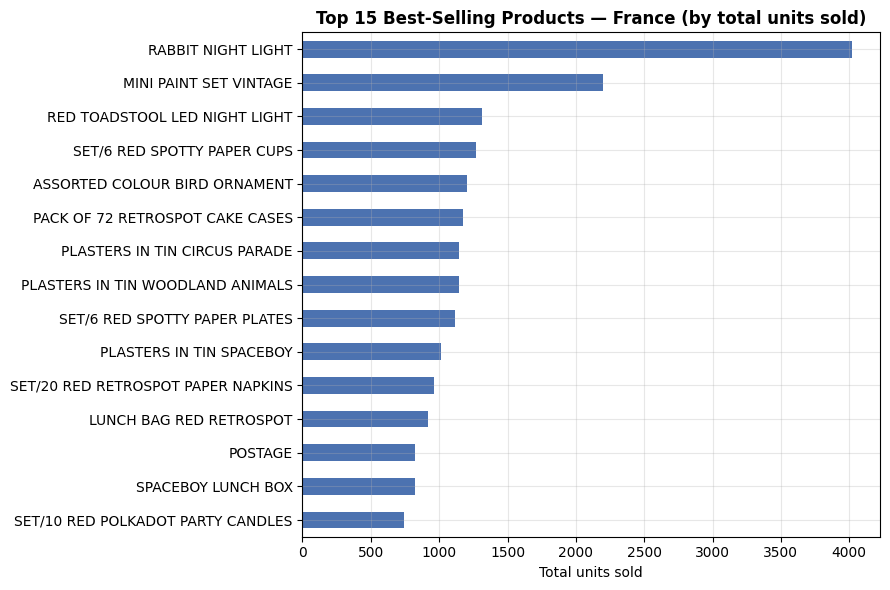

In [3]:
top_products = (df.groupby('Description')['Quantity'].sum()
                  .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 6))
top_products.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 15 Best-Selling Products — France (by total units sold)', fontsize=12, fontweight='bold')
ax.set_xlabel('Total units sold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

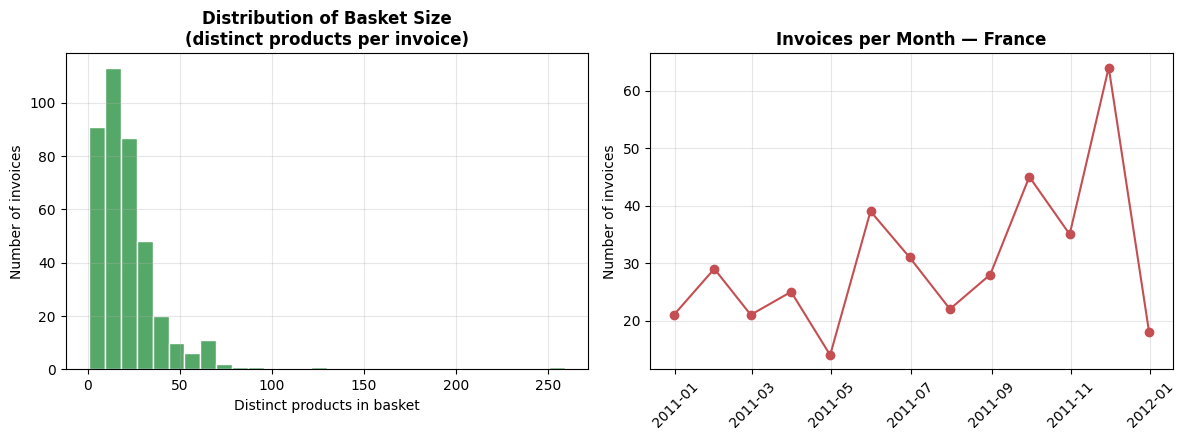

Median basket size: 18 distinct products
Mean basket size:   21.35 distinct products


In [4]:
basket_size = df.groupby('InvoiceNo')['Description'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(basket_size, bins=30, color='#55A868', edgecolor='white')
axes[0].set_title('Distribution of Basket Size\n(distinct products per invoice)', fontweight='bold')
axes[0].set_xlabel('Distinct products in basket')
axes[0].set_ylabel('Number of invoices')

monthly = df.set_index('InvoiceDate').resample('ME')['InvoiceNo'].nunique()
axes[1].plot(monthly.index, monthly.values, marker='o', color='#C44E52')
axes[1].set_title('Invoices per Month — France', fontweight='bold')
axes[1].set_ylabel('Number of invoices')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Median basket size: {basket_size.median():.0f} distinct products")
print(f"Mean basket size:   {basket_size.mean():.2f} distinct products")

<a id="6"></a>
## 6. Building the Transaction–Item Matrix

Apriori needs data in **one-hot encoded basket format**: one row per transaction (invoice), one column per product, with a `1`/`True` if that product appeared in that invoice (quantity is irrelevant for classic MBA — we only care about *presence*).

We also drop the `POSTAGE` "product" if present, since shipping fees are not a purchasable item and would otherwise pollute every rule.

In [5]:
basket = (df.groupby(['InvoiceNo', 'Description'])['Quantity']
            .sum().unstack().reset_index().fillna(0)
            .set_index('InvoiceNo'))

basket_sets = (basket >= 1)

if 'POSTAGE' in basket_sets.columns:
    basket_sets = basket_sets.drop('POSTAGE', axis=1)

print("Transaction-item matrix shape:", basket_sets.shape,
      f"→ {basket_sets.shape[0]} baskets × {basket_sets.shape[1]} distinct products")
basket_sets.iloc[:5, :6]

Transaction-item matrix shape: (392, 1562) → 392 baskets × 1562 distinct products


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 EGG HOUSE PAINTED WOOD,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT
InvoiceNo,,,,,,
536370,False,False,False,False,False,False
536852,False,False,False,False,False,False
536974,False,False,False,False,False,False
537065,False,False,False,False,False,False
537463,False,False,False,False,False,False


<a id="7"></a>
## 7. Worked Numerical Example (by hand)

Before letting the library do the work, let's manually compute Support, Confidence and Lift for one concrete rule, to confirm we understand what the algorithm is doing underneath. We'll use two items that intuitively belong together: **"ALARM CLOCK BAKELIKE RED"** and **"ALARM CLOCK BAKELIKE GREEN"**.

$$\text{Support}(\text{Red}) = \frac{n(\text{Red})}{|D|} \qquad \text{Support}(\text{Green}) = \frac{n(\text{Green})}{|D|} \qquad \text{Support}(\text{Red}\cap\text{Green}) = \frac{n(\text{Red}\cap\text{Green})}{|D|}$$
$$\text{Confidence}(\text{Red}\Rightarrow\text{Green}) = \frac{\text{Support}(\text{Red}\cap\text{Green})}{\text{Support}(\text{Red})} \qquad \text{Lift}(\text{Red}\Rightarrow\text{Green}) = \frac{\text{Confidence}(\text{Red}\Rightarrow\text{Green})}{\text{Support}(\text{Green})}$$

In [6]:
item_a = 'ALARM CLOCK BAKELIKE RED'
item_b = 'ALARM CLOCK BAKELIKE GREEN'

D = len(basket_sets)
n_a   = basket_sets[item_a].sum()
n_b   = basket_sets[item_b].sum()
n_ab  = (basket_sets[item_a] & basket_sets[item_b]).sum()

support_a  = n_a / D
support_b  = n_b / D
support_ab = n_ab / D
confidence_ab = support_ab / support_a
lift_ab = confidence_ab / support_b

print(f"|D| (total baskets)               = {D}")
print(f"n(Red)                            = {n_a}")
print(f"n(Green)                          = {n_b}")
print(f"n(Red ∩ Green)                    = {n_ab}")
print("-" * 55)
print(f"Support(Red)                      = {n_a}/{D} = {support_a:.4f}")
print(f"Support(Green)                    = {n_b}/{D} = {support_b:.4f}")
print(f"Support(Red ∩ Green)              = {n_ab}/{D} = {support_ab:.4f}")
print(f"Confidence(Red ⇒ Green)           = {support_ab:.4f}/{support_a:.4f} = {confidence_ab:.4f}")
print(f"Lift(Red ⇒ Green)                 = {confidence_ab:.4f}/{support_b:.4f} = {lift_ab:.4f}")
print("-" * 55)
print(f"Interpretation: buying the RED alarm clock makes buying the GREEN one")
print(f"about {lift_ab:.1f}x more likely than chance — a strong positive association.")

|D| (total baskets)               = 392
n(Red)                            = 37
n(Green)                          = 38
n(Red ∩ Green)                    = 31
-------------------------------------------------------
Support(Red)                      = 37/392 = 0.0944
Support(Green)                    = 38/392 = 0.0969
Support(Red ∩ Green)              = 31/392 = 0.0791
Confidence(Red ⇒ Green)           = 0.0791/0.0944 = 0.8378
Lift(Red ⇒ Green)                 = 0.8378/0.0969 = 8.6430
-------------------------------------------------------
Interpretation: buying the RED alarm clock makes buying the GREEN one
about 8.6x more likely than chance — a strong positive association.


We'll verify below that `mlxtend`'s `apriori` + `association_rules` reproduce these exact numbers automatically for every itemset pair — that's the value of the algorithm: it does this computation for *every* combination efficiently, using the Apriori pruning principle instead of brute force.

<a id="8"></a>
## 8. Applying the Apriori Algorithm

We mine **frequent itemsets** — itemsets whose support exceeds a minimum threshold `min_support`. We choose `min_support = 0.06` (≈ appearing in at least ~24 of 392 baskets): high enough to filter noise, low enough to surface meaningful multi-item combinations. This threshold is a modeling choice — too high loses interesting rules, too low produces an explosion of low-value ones (see Section 12).

In [7]:
frequent_itemsets = apriori(basket_sets, min_support=0.06, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
print(f"  of which single items:  {(frequent_itemsets['length']==1).sum()}")
print(f"  of which pairs+:        {(frequent_itemsets['length']>=2).sum()}")
frequent_itemsets.head(15)

Frequent itemsets found: 78
  of which single items:  58
  of which pairs+:        20


,support,itemsets,length
34,0.188776,frozenset({RABBIT NIGHT LIGHT}),1
40,0.181122,frozenset({RED TOADSTOOL LED NIGHT LIGHT}),1
32,0.170918,frozenset({PLASTERS IN TIN WOODLAND ANIMALS}),1
29,0.168367,frozenset({PLASTERS IN TIN CIRCUS PARADE}),1
45,0.158163,frozenset({ROUND SNACK BOXES SET OF4 WOODLAND}),1
20,0.153061,frozenset({LUNCH BAG RED RETROSPOT}),1
24,0.142857,frozenset({LUNCH BOX WITH CUTLERY RETROSPOT}),1
30,0.137755,frozenset({PLASTERS IN TIN SPACEBOY}),1
51,0.137755,frozenset({SET/6 RED SPOTTY PAPER CUPS}),1
38,0.137755,frozenset({RED RETROSPOT MINI CASES}),1


<a id="9"></a>
## 9. Generating Association Rules

From the frequent itemsets we generate rules $X \Rightarrow Y$, keeping only those with **Lift ≥ 1** (positive association).

In [8]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift', 'leverage', 'conviction']
print(f"Total association rules generated: {len(rules)}")
rules[display_cols].head(15)

Total association rules generated: 52


,antecedents,consequents,support,confidence,lift,leverage,conviction
0,frozenset({CHILDRENS CUTLERY DOLLY GIRL}),frozenset({CHILDRENS CUTLERY SPACEBOY}),0.063776,0.892857,12.962963,0.058856,8.690476
1,frozenset({CHILDRENS CUTLERY SPACEBOY}),frozenset({CHILDRENS CUTLERY DOLLY GIRL}),0.063776,0.925926,12.962963,0.058856,12.535714
2,frozenset({ALARM CLOCK BAKELIKE RED}),"frozenset({ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",0.063776,0.675676,9.133271,0.056793,2.855230
3,"frozenset({ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",frozenset({ALARM CLOCK BAKELIKE RED}),0.063776,0.862069,9.133271,0.056793,6.565689
4,"frozenset({ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",frozenset({ALARM CLOCK BAKELIKE GREEN}),0.063776,0.862069,8.892922,0.056604,6.547194
5,frozenset({ALARM CLOCK BAKELIKE GREEN}),"frozenset({ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",0.063776,0.657895,8.892922,0.056604,2.706829
6,frozenset({ALARM CLOCK BAKELIKE RED}),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.079082,0.837838,8.642959,0.069932,5.568878
7,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED}),0.079082,0.815789,8.642959,0.069932,4.916181
8,"frozenset({ALARM CLOCK BAKELIKE RED, ALARM CLOCK BAKELIK...",frozenset({ALARM CLOCK BAKELIKE PINK}),0.063776,0.806452,7.903226,0.055706,4.639456
9,frozenset({ALARM CLOCK BAKELIKE PINK}),"frozenset({ALARM CLOCK BAKELIKE RED, ALARM CLOCK BAKELIK...",0.063776,0.625000,7.903226,0.055706,2.455782


In [9]:
strong_rules = rules[(rules['confidence'] >= 0.7) & (rules['lift'] > 3)].sort_values('lift', ascending=False)
print(f"'Strong' rules (confidence ≥ 0.70 and lift > 3): {len(strong_rules)}")
strong_rules[display_cols]

'Strong' rules (confidence ≥ 0.70 and lift > 3): 26


,antecedents,consequents,support,confidence,lift,leverage,conviction
0,frozenset({CHILDRENS CUTLERY DOLLY GIRL}),frozenset({CHILDRENS CUTLERY SPACEBOY}),0.063776,0.892857,12.962963,0.058856,8.690476
1,frozenset({CHILDRENS CUTLERY SPACEBOY}),frozenset({CHILDRENS CUTLERY DOLLY GIRL}),0.063776,0.925926,12.962963,0.058856,12.535714
3,"frozenset({ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",frozenset({ALARM CLOCK BAKELIKE RED}),0.063776,0.862069,9.133271,0.056793,6.565689
4,"frozenset({ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",frozenset({ALARM CLOCK BAKELIKE GREEN}),0.063776,0.862069,8.892922,0.056604,6.547194
6,frozenset({ALARM CLOCK BAKELIKE RED}),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.079082,0.837838,8.642959,0.069932,5.568878
7,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED}),0.079082,0.815789,8.642959,0.069932,4.916181
8,"frozenset({ALARM CLOCK BAKELIKE RED, ALARM CLOCK BAKELIK...",frozenset({ALARM CLOCK BAKELIKE PINK}),0.063776,0.806452,7.903226,0.055706,4.639456
10,frozenset({ALARM CLOCK BAKELIKE RED}),frozenset({ALARM CLOCK BAKELIKE PINK}),0.073980,0.783784,7.681081,0.064348,4.153061
11,frozenset({ALARM CLOCK BAKELIKE PINK}),frozenset({ALARM CLOCK BAKELIKE RED}),0.073980,0.725000,7.681081,0.064348,3.293135
12,frozenset({SET/6 RED SPOTTY PAPER PLATES}),"frozenset({SET/20 RED RETROSPOT PAPER NAPKINS, SET/6 RED...",0.099490,0.780000,7.644000,0.086474,4.081633


<a id="10"></a>
## 10. Visualizing the Rules

Four complementary views: the support–confidence–lift landscape, the top rules ranked by lift, a lift heatmap among the most frequent items, and a network graph of item associations.

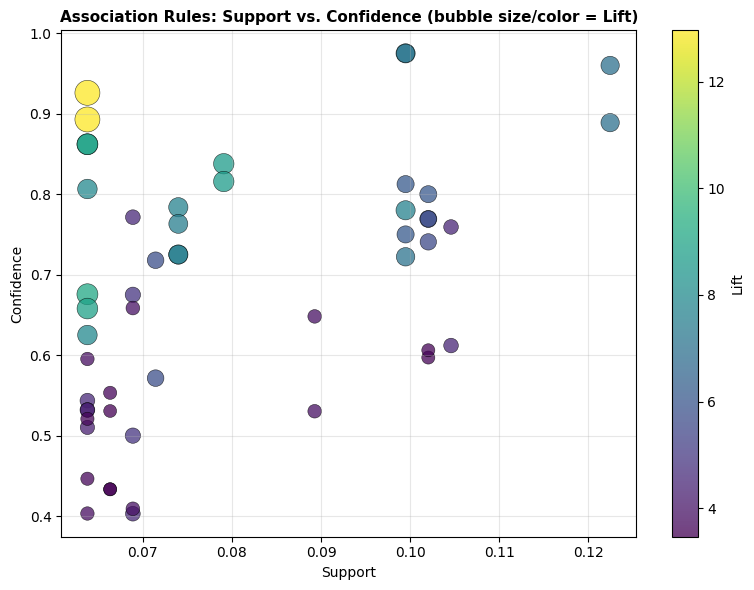

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(rules['support'], rules['confidence'],
                 c=rules['lift'], s=rules['lift']*25, cmap='viridis',
                 alpha=0.75, edgecolor='k', linewidth=0.4)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Lift')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Association Rules: Support vs. Confidence (bubble size/color = Lift)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

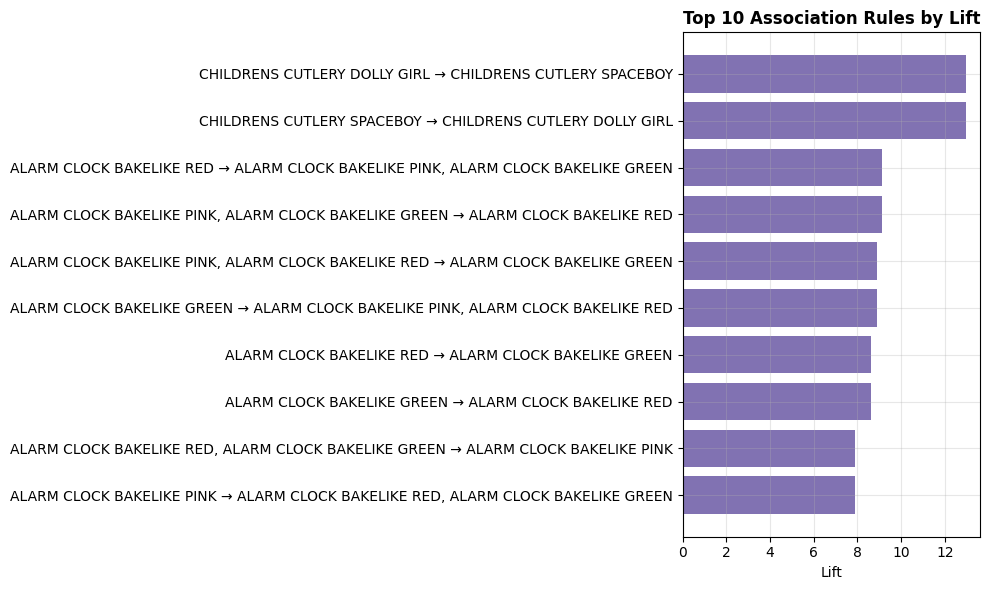

In [11]:
top_n = rules.head(10).copy()
top_n['rule_label'] = top_n.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}", axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_n['rule_label'][::-1], top_n['lift'][::-1], color='#8172B2')
ax.set_xlabel('Lift')
ax.set_title('Top 10 Association Rules by Lift', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

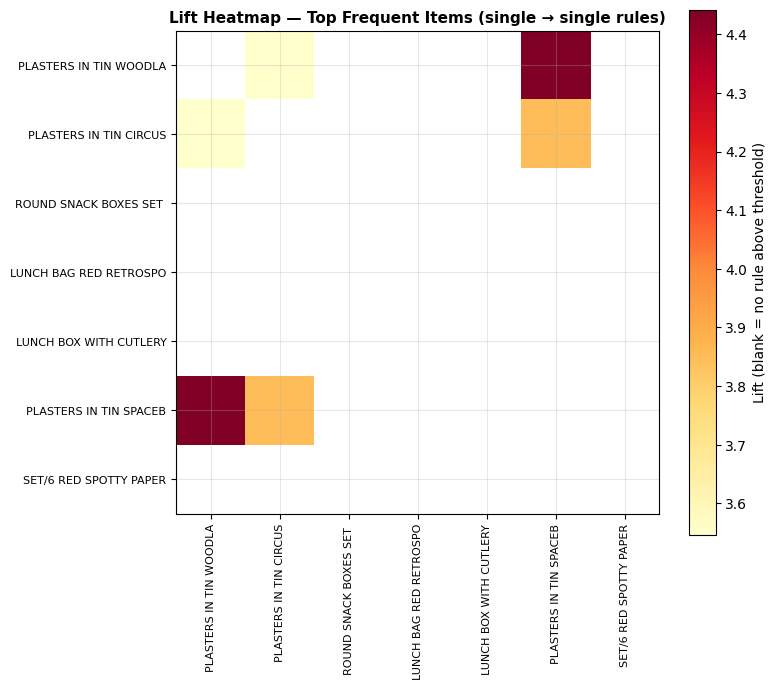

In [12]:
single_items = frequent_itemsets[frequent_itemsets['length'] == 1].sort_values('support', ascending=False)
top_items = [list(s)[0] for s in single_items['itemsets'].head(10)]

pairwise_rules = rules[(rules['antecedents'].apply(lambda x: len(x) == 1)) &
                        (rules['consequents'].apply(lambda x: len(x) == 1))].copy()
pairwise_rules['a'] = pairwise_rules['antecedents'].apply(lambda x: list(x)[0])
pairwise_rules['c'] = pairwise_rules['consequents'].apply(lambda x: list(x)[0])

heat_items = [i for i in top_items if i in set(pairwise_rules['a']) | set(pairwise_rules['c'])]
lift_matrix = pd.DataFrame(index=heat_items, columns=heat_items, dtype=float)
for _, r in pairwise_rules.iterrows():
    if r['a'] in heat_items and r['c'] in heat_items:
        lift_matrix.loc[r['a'], r['c']] = r['lift']

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(lift_matrix.astype(float), cmap='YlOrRd')
ax.set_xticks(range(len(heat_items)))
ax.set_yticks(range(len(heat_items)))
ax.set_xticklabels([i[:22] for i in heat_items], rotation=90, fontsize=8)
ax.set_yticklabels([i[:22] for i in heat_items], fontsize=8)
plt.colorbar(im, ax=ax, label='Lift (blank = no rule above threshold)')
ax.set_title('Lift Heatmap — Top Frequent Items (single → single rules)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

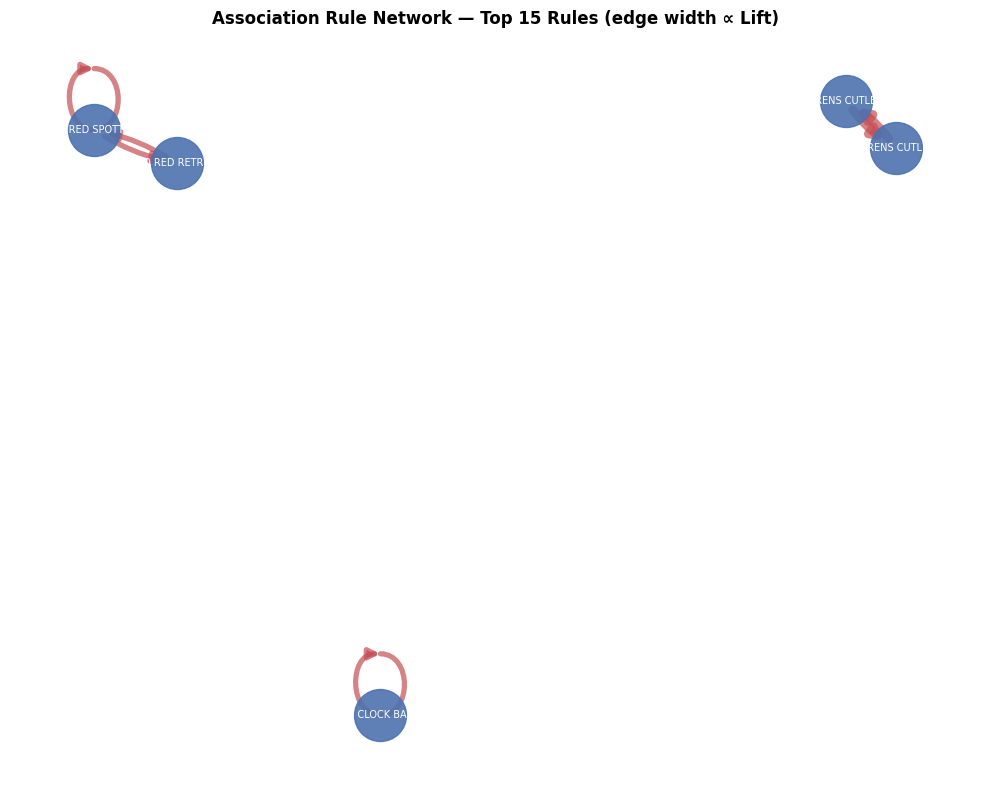

In [13]:
G = nx.DiGraph()
for _, r in rules.head(15).iterrows():
    for a in r['antecedents']:
        for c in r['consequents']:
            G.add_edge(a[:20], c[:20], weight=r['lift'])

pos = nx.spring_layout(G, seed=42, k=0.9)
weights = [G[u][v]['weight'] for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_size=1400, node_color='#4C72B0', alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_color='white', ax=ax)
nx.draw_networkx_edges(G, pos, width=[w/2 for w in weights], edge_color='#C44E52',
                        alpha=0.7, arrowsize=15, connectionstyle='arc3,rad=0.1', ax=ax)
ax.set_title('Association Rule Network — Top 15 Rules (edge width ∝ Lift)', fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

<a id="11"></a>
## 11. Business Interpretation

Reading the top rules by lift:

- **Alarm-clock colour bundles** (`BAKELIKE RED / GREEN / PINK`) show very high lift (≈8–13×) — customers who buy one colour overwhelmingly buy the matching set. This is a clear signal to **bundle these as a multi-pack SKU** or place them adjacent in the online catalogue and physical shelving.
- **Children's cutlery sets** (`DOLLY GIRL` / `SPACEBOY`) show a similarly strong bidirectional association — likely themed gift sets bought as a pair; worth cross-promoting as *"complete the set"* recommendations at checkout.
- High-lift, high-confidence pairs are the best candidates for a **recommendation engine** ("customers who bought this also bought…") and for **promotional bundling** (discount on the pair rather than either item alone, since demand is already coupled).
- Rules with high support but modest lift (close to 1) indicate popular items bought independently — not useful for cross-selling, but useful for general demand forecasting and stock planning.

<a id="12"></a>
## 12. Limitations & Extensions

- **Threshold sensitivity:** `min_support` and `min_confidence`/`lift` cutoffs were chosen manually; lowering `min_support` sharply increases rule count (many spurious/low-value rules), while raising it risks missing genuine but less-frequent bundles. In practice this is tuned against a validation split or business judgement.
- **Scalability:** Apriori's repeated database scans become expensive as the item catalogue grows — here we restricted to France (392 baskets, ~1,500 SKUs) for tractability. For the full dataset (541,909 rows, 38 countries), **FP-Growth** (`mlxtend.frequent_patterns.fpgrowth`) or a distributed implementation (e.g. Spark MLlib's FP-Growth) would be more appropriate, since it avoids candidate generation entirely by mining a compressed FP-tree.
- **No notion of quantity, price, or sequence:** classic MBA only asks "was it bought?", not "how much/when". Extensions such as **weighted association rule mining** (using revenue/quantity) or **sequential pattern mining** (order of purchases across visits) capture richer behaviour.
- **Static snapshot:** customer preferences and seasonal patterns (e.g. gift items around Christmas) shift over time; a production system would re-mine rules periodically rather than once.

<a id="13"></a>
## 13. Conclusion

We applied the Apriori algorithm end-to-end on a **real, publicly-documented e-commerce transaction log** (UCI *Online Retail*): cleaned raw invoice data, built a transaction–item matrix, manually verified the Support/Confidence/Lift formulas on a concrete example, mined frequent itemsets, generated and ranked association rules, and visualized/interpreted the results for concrete cross-selling and bundling recommendations. The strongest rules discovered (colour-themed alarm-clock sets and children's cutlery pairs, lift up to ≈13×) are exactly the kind of actionable, non-obvious pattern MBA is designed to surface.

### References
1. Agrawal, R., & Srikant, R. (1994). *Fast Algorithms for Mining Association Rules*. VLDB.
2. Chen, D., Sain, S. L., & Guo, K. (2012). *Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining*. Journal of Database Marketing & Customer Strategy Management, 19(3), 197–208.
3. Chen, D. (2015). *Online Retail* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33
4. Raschka, S. `mlxtend` documentation — Frequent Pattern Mining. https://rasbt.github.io/mlxtend/